# Exploration - Cameroon

In [1]:
import numpy as np

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd

## Administrative Boundaries

adm1 shape: (10, 22)
adm2 shape: (58, 27)
adm3 shape: (360, 32)


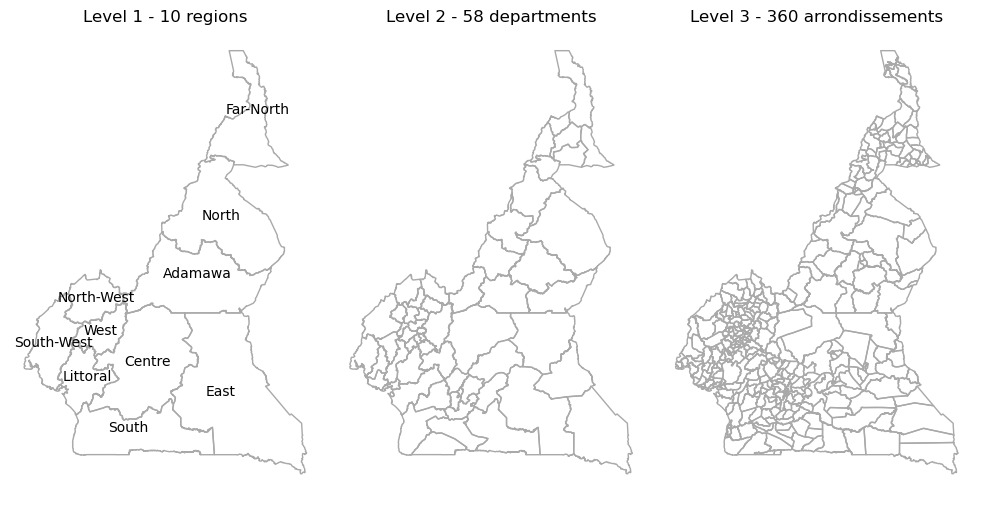

In [20]:
# set this to the folder where you unzipped the files
data_dir = Path(r"../data/input/cmr_admin_boundaries_humdata")

# read shapefiles for each admin level
adm1 = gpd.read_file(data_dir / "cmr_admin1.shp")
adm2 = gpd.read_file(data_dir / "cmr_admin2.shp")
adm3 = gpd.read_file(data_dir / "cmr_admin3.shp")

# quick check: print table size
print("adm1 shape:", adm1.shape)
print("adm2 shape:", adm2.shape)
print("adm3 shape:", adm3.shape)

# quick check: print head
# print(adm1.head())
# print(adm2.head())
# print(adm3.head())

# simple separate plots
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

adm1.plot(ax=axes[0], edgecolor="darkgray", facecolor="none")
axes[0].set_title(f"Level 1 - {len(adm1)} regions")

# add region labels (only level 1)
for _, row in adm1.iterrows():
    p = row.geometry.representative_point()
    axes[0].text(
        p.x, p.y, row["adm1_name"],
        fontsize=10, ha="center", va="center"
    )

adm2.plot(ax=axes[1], edgecolor="darkgray", facecolor="none")
axes[1].set_title(f"Level 2 - {len(adm2)} departments")

adm3.plot(ax=axes[2], edgecolor="darkgray", facecolor="none")
axes[2].set_title(f"Level 3 - {len(adm3)} arrondissements")

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


## DEM: Digital Elevation Model

In [24]:
tiles_dir = Path(r"../data/input/DEM/COP30")   # folder with COP30_*.tif
tif_files = sorted(tiles_dir.glob("COP30_*.tif"))  # adjust pattern if needed

src_files_to_mosaic = [rasterio.open(fp) for fp in tif_files]
# limit merge to Cameroon extent and downsample from ~30m to ~900m
cam_bounds = adm1.to_crs(src_files_to_mosaic[0].crs).total_bounds  # (minx, miny, maxx, maxy)

scale_factor = 900 / 30  # resolution 30m -> 900m
src_res_x, src_res_y = src_files_to_mosaic[0].res
target_res = (src_res_x * scale_factor, src_res_y * scale_factor)

mosaic, out_transform = merge(
    src_files_to_mosaic,
    bounds=tuple(cam_bounds),
    res=target_res,
    resampling=rasterio.enums.Resampling.average,
    dtype="int16",
    nodata=-32768
)

out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform
})

mosaic_path = tiles_dir / "cameroon_dem_30m.tif"
with rasterio.open(mosaic_path, "w", **out_meta) as dest:
    dest.write(mosaic)

for src in src_files_to_mosaic:
    src.close()


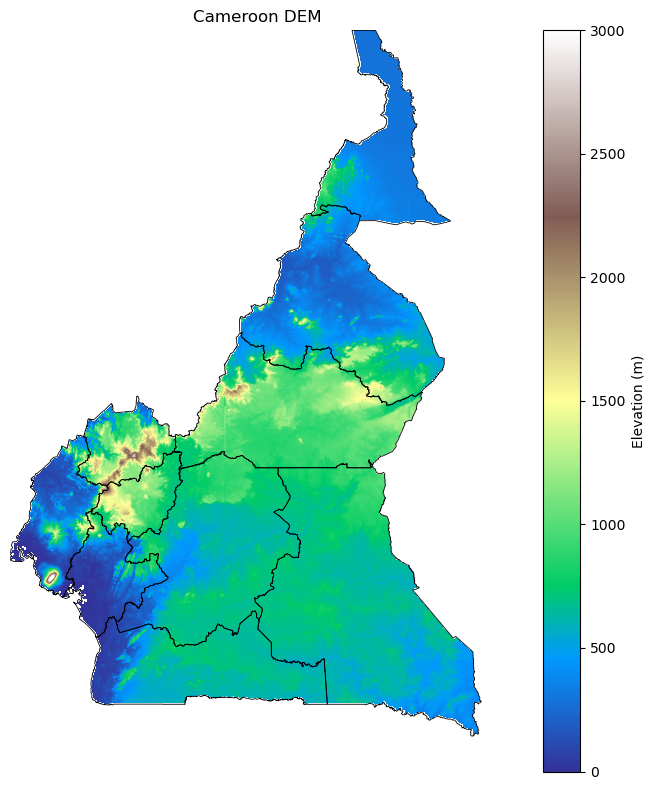

In [42]:
# admin1 shapefile (regions)
admin_dir = Path(r"../data/input/cmr_admin_boundaries_humdata")
adm1 = gpd.read_file(admin_dir / "cmr_admin1.shp")   # or cmr_admin1_em.shp

# clip DEM to admin1 boundaries
with rasterio.open(mosaic_path) as src:
    # reproject polygons to DEM CRS if needed
    adm1_proj = adm1.to_crs(src.crs)

    geoms = [geom for geom in adm1_proj.geometry]
    dem_clipped, dem_transform = mask(src, geoms, crop=True)
    dem_clipped = dem_clipped[0]
    

# plot clipped DEM (only inside Cameroon)
fig, ax = plt.subplots(figsize=(8, 8))

extent = [
    dem_transform * (0, 0),
    dem_transform * (dem_clipped.shape[1], dem_clipped.shape[0])
]
# transform returns (x, y); unpack for extent
xmin, ymax = extent[0]
xmax, ymin = extent[1]

im = ax.imshow(
    dem_clipped,
    extent=[xmin, xmax, ymin, ymax],
    cmap="terrain",
    origin="upper"
)

# set color scale limits (adjust values as needed)
vmin, vmax = 0, 3000
im.set_clim(vmin=vmin, vmax=vmax)

plt.colorbar(im, ax=ax, label="Elevation (m)")

# optional: draw borders on top for clarity
adm1_proj.boundary.plot(ax=ax, edgecolor="black", linewidth=0.6)

# use white as for cells outside Cameroon shape
cmap = im.get_cmap().copy()
cmap.set_bad(color="white")
im.set_cmap(cmap)
im.set_data(np.ma.masked_equal(dem_clipped, 0))

ax.set_title("Cameroon DEM")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Forest Change